In [ ]:
!pip install Flask
!npm install -g localtunnel



added 22 packages, and audited 23 packages in 4s

3 packages are looking for funding
  run `npm fund` for details

1 moderate severity vulnerability

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.


In [ ]:
from flask import Flask, render_template

app = Flask(__name__)

@app.route('/')
def home():
    return render_template('index.html')

if __name__ == '__main__':
    app.run(port=5000)


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
import subprocess
lt_process = subprocess.Popen(["lt", "--port", "5000"])


In [ ]:
import kagglehub

# Download latest version
# path="hamzahabib47/brain-cancer-detection-mri-images"
path = kagglehub.dataset_download("hamzahabib47/brain-cancer-detection-mri-images")

print("Path to dataset files:", path)

100%|██████████| 13.9M/13.9M [00:00<00:00, 23.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hamzahabib47/brain-cancer-detection-mri-images/versions/3


In [ ]:
!pip install -Uqq fastai
from fastai.vision.all import *

In [ ]:
from pathlib import Path

# Convert your directory to a Path object
path = Path(path)  # replace with your path

# Check if the directory exists and print its contents
if path.exists():
    print("Path exists.")
    print("Files in the directory:", list(path.iterdir()))  # Lists all files
else:
    print("Path does not exist.")


Path exists.
Files in the directory: [Path('/root/.cache/kagglehub/datasets/hamzahabib47/brain-cancer-detection-mri-images/versions/3/Dataset')]


In [ ]:
get_image_files(path)

(#800) [Path('/root/.cache/kagglehub/datasets/hamzahabib47/brain-cancer-detection-mri-images/versions/3/Dataset/healthy/healthy (25).jpg'),Path('/root/.cache/kagglehub/datasets/hamzahabib47/brain-cancer-detection-mri-images/versions/3/Dataset/healthy/healthy (47).jpg'),Path('/root/.cache/kagglehub/datasets/hamzahabib47/brain-cancer-detection-mri-images/versions/3/Dataset/healthy/healthy (394).jpg'),Path('/root/.cache/kagglehub/datasets/hamzahabib47/brain-cancer-detection-mri-images/versions/3/Dataset/healthy/healthy (2).jpg'),Path('/root/.cache/kagglehub/datasets/hamzahabib47/brain-cancer-detection-mri-images/versions/3/Dataset/healthy/healthy (242).jpg'),Path('/root/.cache/kagglehub/datasets/hamzahabib47/brain-cancer-detection-mri-images/versions/3/Dataset/healthy/healthy (343).jpg'),Path('/root/.cache/kagglehub/datasets/hamzahabib47/brain-cancer-detection-mri-images/versions/3/Dataset/healthy/healthy (185).jpg'),Path('/root/.cache/kagglehub/datasets/hamzahabib47/brain-cancer-detectio

<Axes: >

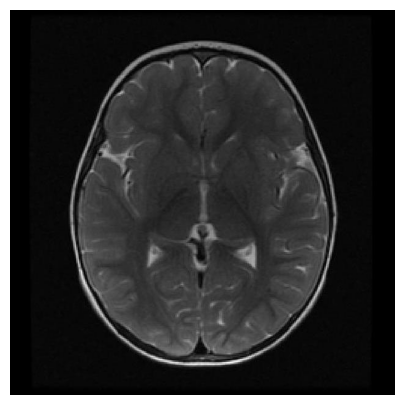

In [ ]:
img=PILImage.create(get_image_files(path)[13])
img.show()

In [ ]:
len(get_image_files(path))

800

In [ ]:
label1='healthy'
label2='tumor'

In [ ]:
# do not use it will remove the images
# do not use
# do not use
# do not use

for img in get_image_files(path):
  if label1 in str(img):
    img.rename(f"{img.parent}/{label1}_{img.name}")
  elif label2 in str(img):
    img.rename(f"{img.parent}/{label2}_{img.name}")
  else:os.remove(img) #removing the other images from the dataset
len(get_image_files(path))

800

In [ ]:
def getlabel(fileName):
  return fileName.split('_')[0]

getlabel("health(1).jpg") #testing

'health(1).jpg'

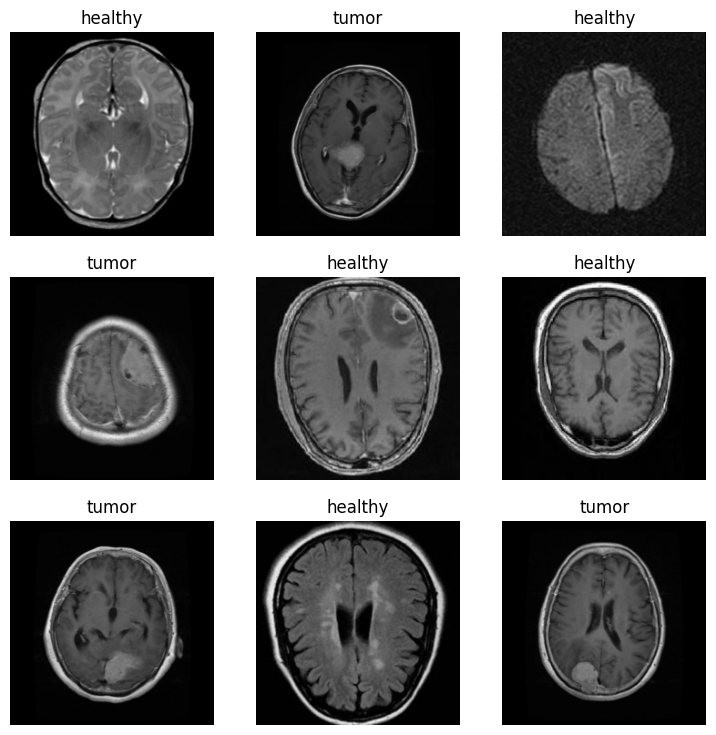

In [ ]:
dls=ImageDataLoaders.from_name_func(
    path,get_image_files(path),valid_pct=0.2,seed=421,#0.2 is twenty percent of the data for testing
    label_func=getlabel,item_tfms=Resize(224)
)

dls.valid.show_batch()

In [ ]:
learn=cnn_learner(dls,resnet34,metrics=error_rate,pretrained=True)
learn.fine_tune(epochs=4)

/usr/local/lib/python3.10/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:02<00:00, 41.1MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.731461,0.358022,0.156250,04:39


epoch,train_loss,valid_loss,error_rate,time
0,0.188742,0.158045,0.056250,06:03
1,0.122324,0.052448,0.012500,05:54
2,0.084540,0.091867,0.025000,05:59
3,0.062573,0.041748,0.006250,05:56
4,0.047982,0.070581,0.018750,06:01
5,0.039028,0.046519,0.012500,06:05
6,0.030920,0.042017,0.006250,06:00
7,0.024636,0.041820,0.006250,05:57
8,0.019525,0.041791,0.006250,05:55
9,0.015679,0.041230,0.006250,05:55


Saving OIP(3).jpg to OIP(3).jpg


This is a healthy
healthy0.000000
healthy1.000000


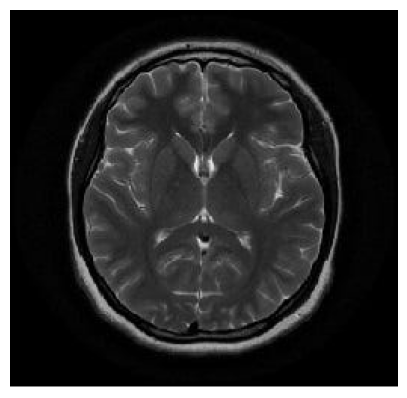

In [ ]:
from google.colab import files
uploader=files.upload()
for img in uploader.items():
  uploadingImg=img[0]

img=PILImage.create(uploadingImg)
img.show()

label,_,probs=learn.predict(img)

print(f"This is a {label}")


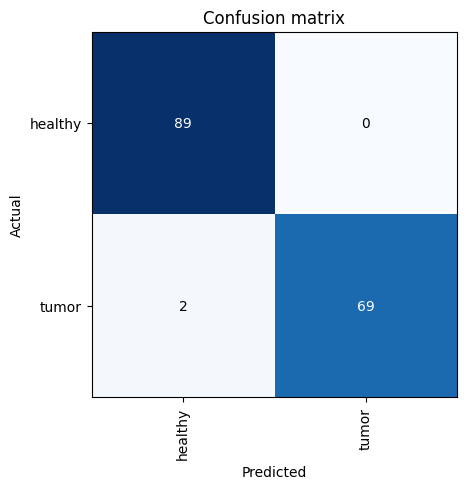

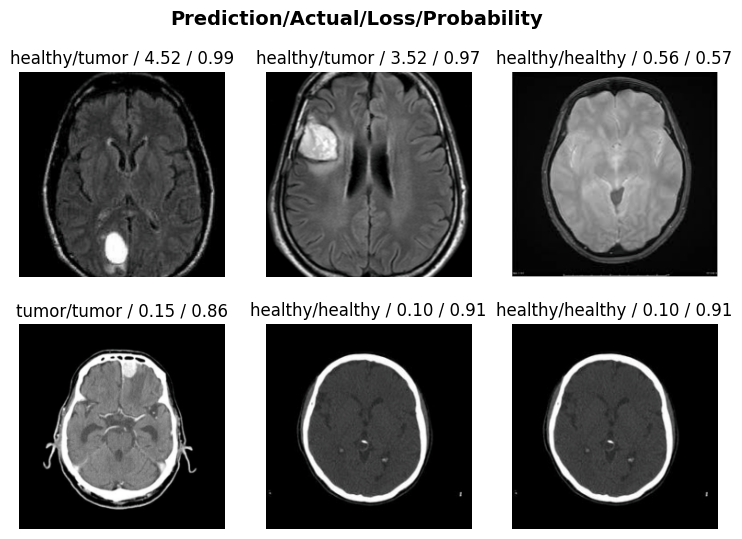

In [ ]:
interp=ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(6)

In [ ]:
from google.colab import output

# Step 1: Define the function that will be called when the button is clicked
def execute_code(arg1, arg2):
    print(f"Function executed with arguments: {arg1}, {arg2}")

# Step 2: Register the function as a callback
output.register_callback('notebook.execute_code', execute_code)



In [ ]:
learn.export()

In [ ]:
modelPath=get_files(path,'.pkl')[0]
modelPath

Path('/root/.cache/kagglehub/datasets/hamzahabib47/brain-cancer-detection-mri-images/versions/3/export.pkl')

In [ ]:
import matplotlib.image as mpimg

learn_inf=load_learner(modelPath)
learn_inf.predict(mpimg.imread(get_image_files(path)[0]))

('tumor', tensor(1), tensor([1.6186e-09, 1.0000e+00]))

In [ ]:
learn_inf.dls.vocab

['healthy', 'tumor']

In [ ]:
from google.colab import files
files.download(modelPath)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>